In [1]:
# Colab setup
!pip -q install -U 'transformers>=4.56.0' 'huggingface_hub>=0.34.0'

In [2]:
import json
import os
import platform
import sys
import traceback
from dataclasses import asdict, dataclass

import torch
from PIL import Image, ImageDraw
from torchvision.transforms import v2

print(f'Python: {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type == 'cuda', 'Enable a GPU runtime in Colab before continuing.'

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## DINOv3 access check

In [3]:
# Access via 'huggingface'
# Spoilers: It will fail due to Meta AI gated access policies and restrictions
DINO3_LOAD_MODE = 'huggingface'
DINO3_MODEL_ID = 'facebook/dinov3-vits16plus-pretrain-lvd1689m'

# Required only for DINO3_LOAD_MODE == 'torchhub'.

def get_hf_token():
    # Prefer a Colab Secret. An environment variable is useful outside Colab.
    token = os.environ.get('HF_TOKEN')
    if token:
        return token
    try:
        from google.colab import userdata
        return userdata.get('HF_TOKEN')
    except Exception:
        return None

HF_TOKEN = get_hf_token()
print('HF_TOKEN available:', bool(HF_TOKEN))

HF_TOKEN available: False


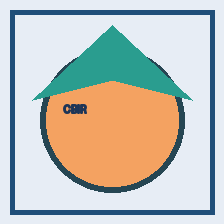

Test tensor: (1, 3, 224, 224) torch.float32 cuda:0


In [4]:
# Make a sample RGB image.
def make_sample_image(size=224):
    image = Image.new('RGB', (size, size), '#e7edf5')
    draw = ImageDraw.Draw(image)
    draw.rectangle((10, 10, size - 10, size - 10), outline='#1f4e79', width=5)
    draw.ellipse((40, 48, 184, 192), fill='#f4a261', outline='#264653', width=6)
    draw.polygon([(112, 25), (192, 100), (112, 80), (32, 100)], fill='#2a9d8f')
    draw.text((64, 103), 'CBIR', fill='#1d3557', stroke_width=1)
    return image

sample_image = make_sample_image()
display(sample_image)

# Access test
test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
test_pixels = test_transform(sample_image).unsqueeze(0).to(DEVICE)
print('Test tensor:', tuple(test_pixels.shape), test_pixels.dtype, test_pixels.device)

In [5]:
@dataclass
class CheckResult:
    name: str
    status: str
    parameters_millions: float | None = None
    output_summary: str | None = None
    error: str | None = None

def parameter_count_millions(model):
    return sum(p.numel() for p in model.parameters()) / 1_000_000

def summarize_output(output):
    if torch.is_tensor(output):
        return f'Tensor shape={tuple(output.shape)}, dtype={output.dtype}'
    if hasattr(output, 'last_hidden_state') and output.last_hidden_state is not None:
        return f'last_hidden_state shape={tuple(output.last_hidden_state.shape)}, dtype={output.last_hidden_state.dtype}'
    if isinstance(output, dict):
        pieces = []
        for key, value in output.items():
            if torch.is_tensor(value):
                pieces.append(f'{key}={tuple(value.shape)}')
        return '; '.join(pieces) or f'dict keys={list(output.keys())}'
    return repr(type(output))

def run_check(name, loader, forward):
    print(f'\n--- {name} ---')
    try:
        model = loader().eval().to(DEVICE)
        with torch.inference_mode():
            output = forward(model)
        result = CheckResult(
            name=name,
            status='SUCCESS',
            parameters_millions=round(parameter_count_millions(model), 3),
            output_summary=summarize_output(output),
        )
        print(f'PASS — {result.parameters_millions}M parameters')
        print(result.output_summary)
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return result
    except Exception as exc:
        result = CheckResult(
            name=name,
            status='FAILED',
            error=f'{type(exc).__name__}: {exc}',
        )
        print('NOT AVAILABLE / FAILED')
        print(result.error)
        return result

In [6]:
# Preferred backbone: DINOv3 ViT-S+/16.
def load_dinov3():
    if DINO3_LOAD_MODE == 'huggingface':
        from transformers import AutoModel
        kwargs = {'trust_remote_code': False}
        if HF_TOKEN:
            kwargs['token'] = HF_TOKEN
        return AutoModel.from_pretrained(DINO3_MODEL_ID, **kwargs)

    raise ValueError("DINO3_LOAD_MODE must be 'huggingface'.")

def forward_dinov3(model):
    # Hugging Face exposes all transformer-layer states, which our later cache builder needs.
    if DINO3_LOAD_MODE == 'huggingface':
        output = model(pixel_values=test_pixels, output_hidden_states=True)
        print('Hidden-state tensors:', len(output.hidden_states))
        print('First/last hidden shapes:', tuple(output.hidden_states[0].shape), tuple(output.hidden_states[-1].shape))
        return output
    return model(test_pixels)

results = []
results.append(run_check('DINOv3 ViT-S+/16 (preferred)', load_dinov3, forward_dinov3))


--- DINOv3 ViT-S+/16 (preferred) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


NOT AVAILABLE / FAILED
OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m.
401 Client Error. (Request ID: Root=1-6a6dbdcc-1891a45a10230c4408f634fc;7d201de8-23a9-4f9b-98ef-b51295c53181)

Cannot access gated repo for url https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/config.json.
Access to model facebook/dinov3-vits16plus-pretrain-lvd1689m is restricted. You must have access to it and be authenticated to access it. Please log in.


# DINOv2 fallback

In [7]:
def load_dinov2_without_registers():
    return torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', trust_repo=True)

def load_dinov2_with_registers():
    return torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg', trust_repo=True)

results.append(run_check(
    'DINOv2 ViT-S/14 (without registers)',
    load_dinov2_without_registers,
    lambda model: model(test_pixels),
))
results.append(run_check(
    'DINOv2 ViT-S/14 (with 4 registers)',
    load_dinov2_with_registers,
    lambda model: model(test_pixels),
))


--- DINOv2 ViT-S/14 (without registers) ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


PASS — 22.057M parameters
Tensor shape=(1, 384), dtype=torch.float32

--- DINOv2 ViT-S/14 (with 4 registers) ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


PASS — 22.058M parameters
Tensor shape=(1, 384), dtype=torch.float32


In [8]:
# Final decision
summary = [asdict(result) for result in results]
print(json.dumps(summary, indent=2))

preferred = results[0]
if preferred.status == 'SUCCESS':
    print('\nDecision: DINOv3 ViT-S+/16 is accessible. Using it.')
elif results[2].status == 'SUCCESS':
    print('\nDecision: DINOv2 ViT-S/14 with registers is accessible. Using it.')
elif results[1].status == 'SUCCESS':
    print('\nDecision: DINOv2 ViT-S/14 without registers is accessible. Using it.')
else:
    print('\nDecision: no backbone passed.')

[
  {
    "name": "DINOv3 ViT-S+/16 (preferred)",
    "status": "FAILED",
    "parameters_millions": null,
    "output_summary": null,
    "error": "OSError: You are trying to access a gated repo.\nMake sure to have access to it at https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m.\n401 Client Error. (Request ID: Root=1-6a6dbdcc-1891a45a10230c4408f634fc;7d201de8-23a9-4f9b-98ef-b51295c53181)\n\nCannot access gated repo for url https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/config.json.\nAccess to model facebook/dinov3-vits16plus-pretrain-lvd1689m is restricted. You must have access to it and be authenticated to access it. Please log in."
  },
  {
    "name": "DINOv2 ViT-S/14 (without registers)",
    "status": "SUCCESS",
    "parameters_millions": 22.057,
    "output_summary": "Tensor shape=(1, 384), dtype=torch.float32",
    "error": null
  },
  {
    "name": "DINOv2 ViT-S/14 (with 4 registers)",
    "status": "SUCCESS",
    "paramete